In [18]:
# =========================================================
# 第12週
# 得点機会の量と4番打者の成績の関係
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib


# =========================================================
# 1. データの読み込み
# =========================================================

df = pd.read_csv("決定版.csv")

# 列名の確認
print(df.columns.tolist())

# データの先頭を確認
display(df.head())

['日付', '球団', '対戦相手', '打者名', '打順', 'イニング', '表裏', 'イニング内打席番号', '自チーム打席前得点', '相手チーム打席前得点', '打席前点差', '打席前アウト数', '打席前走者状況コード', '打席前一塁走者', '打席前二塁走者', '打席前三塁走者', '打席前状況コード', '打席結果', 'この打席得点数', '打点', '自チーム打席後得点', '相手チーム打席後得点', '打席後点差', '打席後アウト数', '打席後走者状況コード', '打席後一塁走者', '打席後二塁走者', '打席後三塁走者', '打席後状況コード', '得点圏フラグ', '打者走者進塁先', '打席前RE', '打席後RE', 'RE24', '打席前WE', '打席後WE', 'WPA', 'WEサンプル数_前', 'WEサンプル数_後']


,日付,球団,対戦相手,打者名,打順,イニング,表裏,イニング内打席番号,自チーム打席前得点,相手チーム打席前得点,...,得点圏フラグ,打者走者進塁先,打席前RE,打席後RE,RE24,打席前WE,打席後WE,WPA,WEサンプル数_前,WEサンプル数_後
0,2025-03-28,巨人,ヤクルト,岡本 和真,4,1,裏,4,0,0,...,1,0,1.016,0.431,-0.585,0.714286,0.521739,-0.192547,14,23
1,2025-03-28,ヤクルト,巨人,サンタナ,4,2,表,1,0,0,...,0,0,0.365,0.189,-0.176,0.463250,0.432540,-0.030710,517,378
2,2025-03-28,巨人,ヤクルト,岡本 和真,4,3,裏,2,0,0,...,0,0,0.189,0.074,-0.115,0.526906,0.505525,-0.021381,223,181
3,2025-03-28,ヤクルト,巨人,サンタナ,4,5,表,1,0,0,...,0,1,0.365,0.675,0.310,0.479167,0.632353,0.153186,192,34
4,2025-03-28,ヤクルト,巨人,サンタナ,4,6,表,1,4,0,...,0,4,0.365,0.365,1.000,0.871795,0.875000,0.003205,39,16


In [23]:
# =========================================================
# 2. 選手ごとに集計するための準備
# =========================================================

# 列名の前後にある空白を削除
df.columns = df.columns.str.strip()

print("現在の列名")
print(df.columns.tolist())


# ---------------------------------------------------------
# 選手名の列を判定
# ---------------------------------------------------------

if "選手名" in df.columns:
    player_col = "選手名"

elif "打者名" in df.columns:
    player_col = "打者名"

elif "打者" in df.columns:
    player_col = "打者"

else:
    raise KeyError(
        "選手名に該当する列が見つかりません。"
    )


# ---------------------------------------------------------
# 必要な列を数値型に変換
# ---------------------------------------------------------

numeric_columns = [
    "打点",
    "RE24",
    "WPA",
    "得点圏フラグ"
]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )


# ---------------------------------------------------------
# 1行を1打席としてPA用の列を作る
# ---------------------------------------------------------

df["PA用"] = 1


print("使用する選手名の列:", player_col)

display(
    df[
        [
            player_col,
            "PA用",
            "得点圏フラグ",
            "打点",
            "RE24",
            "WPA"
        ]
    ].head()
)

現在の列名
['日付', '球団', '対戦相手', '打者名', '打順', 'イニング', '表裏', 'イニング内打席番号', '自チーム打席前得点', '相手チーム打席前得点', '打席前点差', '打席前アウト数', '打席前走者状況コード', '打席前一塁走者', '打席前二塁走者', '打席前三塁走者', '打席前状況コード', '打席結果', 'この打席得点数', '打点', '自チーム打席後得点', '相手チーム打席後得点', '打席後点差', '打席後アウト数', '打席後走者状況コード', '打席後一塁走者', '打席後二塁走者', '打席後三塁走者', '打席後状況コード', '得点圏フラグ', '打者走者進塁先', '打席前RE', '打席後RE', 'RE24', '打席前WE', '打席後WE', 'WPA', 'WEサンプル数_前', 'WEサンプル数_後', 'PA']
使用する選手名の列: 打者名


,打者名,PA用,得点圏フラグ,打点,RE24,WPA
0,岡本 和真,1,1,0,-0.585,-0.192547
1,サンタナ,1,0,0,-0.176,-0.030710
2,岡本 和真,1,0,0,-0.115,-0.021381
3,サンタナ,1,0,0,0.310,0.153186
4,サンタナ,1,0,1,1.000,0.003205


In [24]:
# =========================================================
# 3. 選手別集計データの作成
# =========================================================

df_player = (
    df.groupby(
        player_col,
        as_index=False
    )
    .agg(
        PA=("PA用", "sum"),
        得点圏打席数=("得点圏フラグ", "sum"),
        打点=("打点", "sum"),
        RE24=("RE24", "sum"),
        WPA=("WPA", "sum")
    )
)


# 選手名の列名を統一
df_player = df_player.rename(
    columns={
        player_col: "選手名"
    }
)


# PA100以上の選手に限定
df_100 = df_player[
    df_player["PA"] >= 100
].copy()


print("集計した選手数:", len(df_player))
print("PA100以上の選手数:", len(df_100))

print("df_100の列名")
print(df_100.columns.tolist())

display(df_100.head())

集計した選手数: 162
PA100以上の選手数: 25
df_100の列名
['選手名', 'PA', '得点圏打席数', '打点', 'RE24', 'WPA']


,選手名,PA,得点圏打席数,打点,RE24,WPA
1,オスナ,273,77,30,3.214,0.736590
3,オースティン,210,53,26,5.493,1.218329
5,キャベッジ,157,52,26,10.538,1.219419
9,ソト,179,45,18,-1.956,-0.638764
11,ネビン,491,120,54,21.654,0.468037


In [25]:
# =========================================================
# 4. 得点圏打席数と打点の相関
# =========================================================

risp_pa_col = "得点圏打席数"

analysis_rbi = df_100[
    [
        "選手名",
        risp_pa_col,
        "打点"
    ]
].copy()

analysis_rbi[risp_pa_col] = pd.to_numeric(
    analysis_rbi[risp_pa_col],
    errors="coerce"
)

analysis_rbi["打点"] = pd.to_numeric(
    analysis_rbi["打点"],
    errors="coerce"
)

analysis_rbi = analysis_rbi.dropna(
    subset=[
        risp_pa_col,
        "打点"
    ]
)

correlation_rbi = analysis_rbi[
    risp_pa_col
].corr(
    analysis_rbi["打点"]
)

print(
    f"分析対象選手数: "
    f"{len(analysis_rbi)}人"
)

print(
    f"得点圏打席数と打点の相関係数: "
    f"{correlation_rbi:.4f}"
)

display(analysis_rbi)

分析対象選手数: 25人
得点圏打席数と打点の相関係数: 0.8802


,選手名,得点圏打席数,打点
1,オスナ,77,30
3,オースティン,53,26
5,キャベッジ,52,26
9,ソト,45,18
11,ネビン,120,54
15,フランコ,31,8
18,ボイト,31,17
19,ボスラー,49,13
22,モンテロ,53,18
23,レイエス,44,40


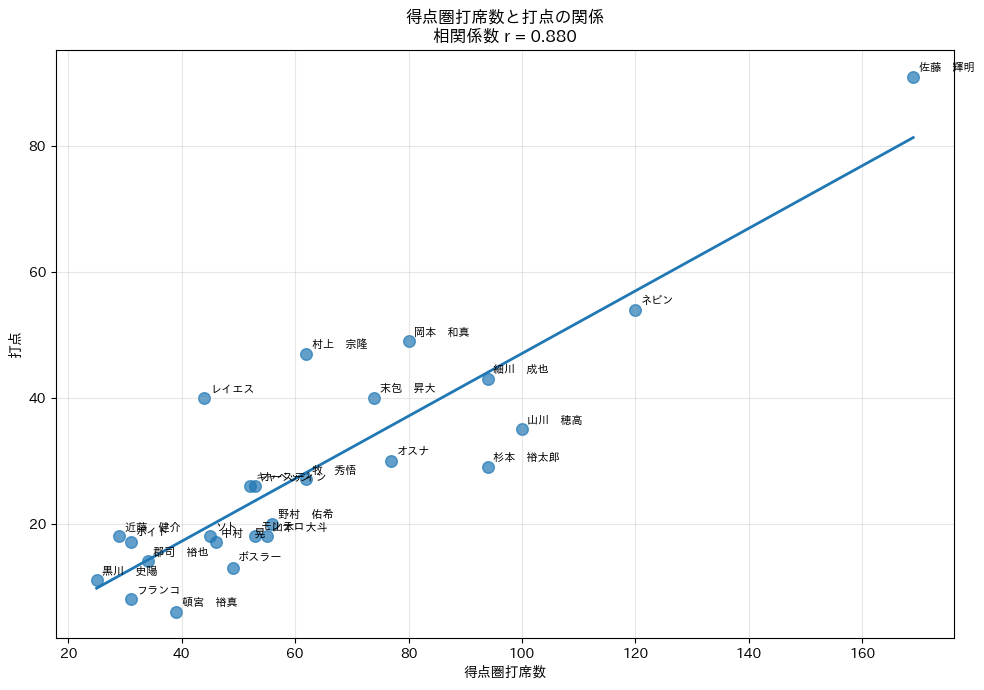

In [26]:
# =========================================================
# 5. 得点圏打席数と打点の散布図
# =========================================================

x = analysis_rbi["得点圏打席数"]
y = analysis_rbi["打点"]

plt.figure(figsize=(10, 7))

plt.scatter(
    x,
    y,
    s=70,
    alpha=0.7
)

# 回帰直線
slope, intercept = np.polyfit(
    x,
    y,
    1
)

x_line = np.linspace(
    x.min(),
    x.max(),
    100
)

y_line = slope * x_line + intercept

plt.plot(
    x_line,
    y_line,
    linewidth=2
)

# 選手名を表示
for _, row in analysis_rbi.iterrows():
    plt.annotate(
        row["選手名"],
        (
            row["得点圏打席数"],
            row["打点"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("得点圏打席数")
plt.ylabel("打点")

plt.title(
    "得点圏打席数と打点の関係\n"
    f"相関係数 r = {correlation_rbi:.3f}"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# =========================================================
# 6. 得点圏打席数とRE24の相関
# =========================================================

analysis_re24 = df_100[
    [
        "選手名",
        "得点圏打席数",
        "RE24"
    ]
].copy()

analysis_re24["得点圏打席数"] = pd.to_numeric(
    analysis_re24["得点圏打席数"],
    errors="coerce"
)

analysis_re24["RE24"] = pd.to_numeric(
    analysis_re24["RE24"],
    errors="coerce"
)

analysis_re24 = analysis_re24.dropna(
    subset=[
        "得点圏打席数",
        "RE24"
    ]
)

correlation_re24 = analysis_re24[
    "得点圏打席数"
].corr(
    analysis_re24["RE24"]
)

print(
    f"得点圏打席数とRE24の相関係数: "
    f"{correlation_re24:.4f}"
)

得点圏打席数とRE24の相関係数: 0.5459


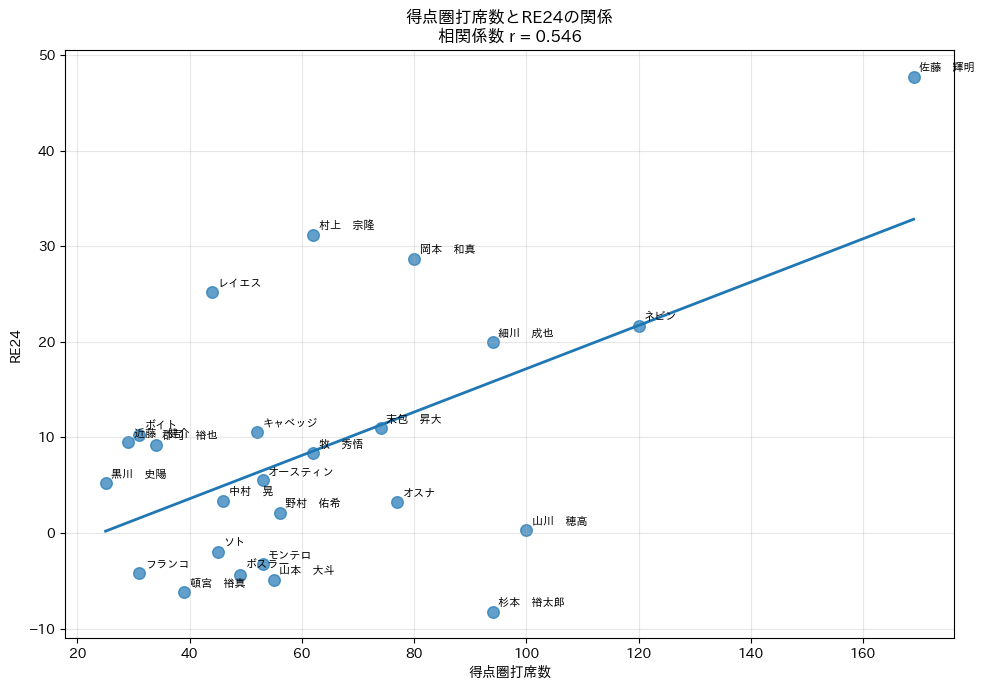

In [28]:
# =========================================================
# 7. 得点圏打席数とRE24の散布図
# =========================================================

x = analysis_re24["得点圏打席数"]
y = analysis_re24["RE24"]

plt.figure(figsize=(10, 7))

plt.scatter(
    x,
    y,
    s=70,
    alpha=0.7
)

# 回帰直線
slope, intercept = np.polyfit(
    x,
    y,
    1
)

x_line = np.linspace(
    x.min(),
    x.max(),
    100
)

y_line = slope * x_line + intercept

plt.plot(
    x_line,
    y_line,
    linewidth=2
)

# 選手名を表示
for _, row in analysis_re24.iterrows():
    plt.annotate(
        row["選手名"],
        (
            row["得点圏打席数"],
            row["RE24"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("得点圏打席数")
plt.ylabel("RE24")

plt.title(
    "得点圏打席数とRE24の関係\n"
    f"相関係数 r = {correlation_re24:.3f}"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# =========================================================
# 8. 得点圏打席数と打点による4分類
# =========================================================

chance_median = df_100["得点圏打席数"].median()
rbi_median = df_100["打点"].median()

print(f"得点圏打席数の中央値: {chance_median:.1f}")
print(f"打点の中央値: {rbi_median:.1f}")


def classify_rbi_type(row):
    chance_high = row["得点圏打席数"] >= chance_median
    rbi_high = row["打点"] >= rbi_median

    if chance_high and rbi_high:
        return "チャンス多・打点多"
    elif chance_high and not rbi_high:
        return "チャンス多・打点少"
    elif not chance_high and rbi_high:
        return "チャンス少・打点多"
    else:
        return "チャンス少・打点少"


df_100["打点タイプ"] = df_100.apply(
    classify_rbi_type,
    axis=1
)

display(
    df_100[
        [
            "選手名",
            "得点圏打席数",
            "打点",
            "RE24",
            "WPA",
            "打点タイプ"
        ]
    ].sort_values(
        [
            "打点タイプ",
            "打点"
        ],
        ascending=[
            True,
            False
        ]
    )
)

得点圏打席数の中央値: 53.0
打点の中央値: 26.0


,選手名,得点圏打席数,打点,RE24,WPA,打点タイプ
42,佐藤 輝明,169,91,47.723,3.238965,チャンス多・打点多
11,ネビン,120,54,21.654,0.468037,チャンス多・打点多
81,岡本 和真,80,49,28.686,4.366410,チャンス多・打点多
93,村上 宗隆,62,47,31.171,4.020346,チャンス多・打点多
134,細川 成也,94,43,19.930,3.654191,チャンス多・打点多
90,末包 昇大,74,40,10.932,-0.075041,チャンス多・打点多
76,山川 穂高,100,35,0.287,0.849737,チャンス多・打点多
1,オスナ,77,30,3.214,0.736590,チャンス多・打点多
91,杉本 裕太郎,94,29,-8.236,0.965217,チャンス多・打点多
113,牧 秀悟,62,27,8.321,5.049012,チャンス多・打点多


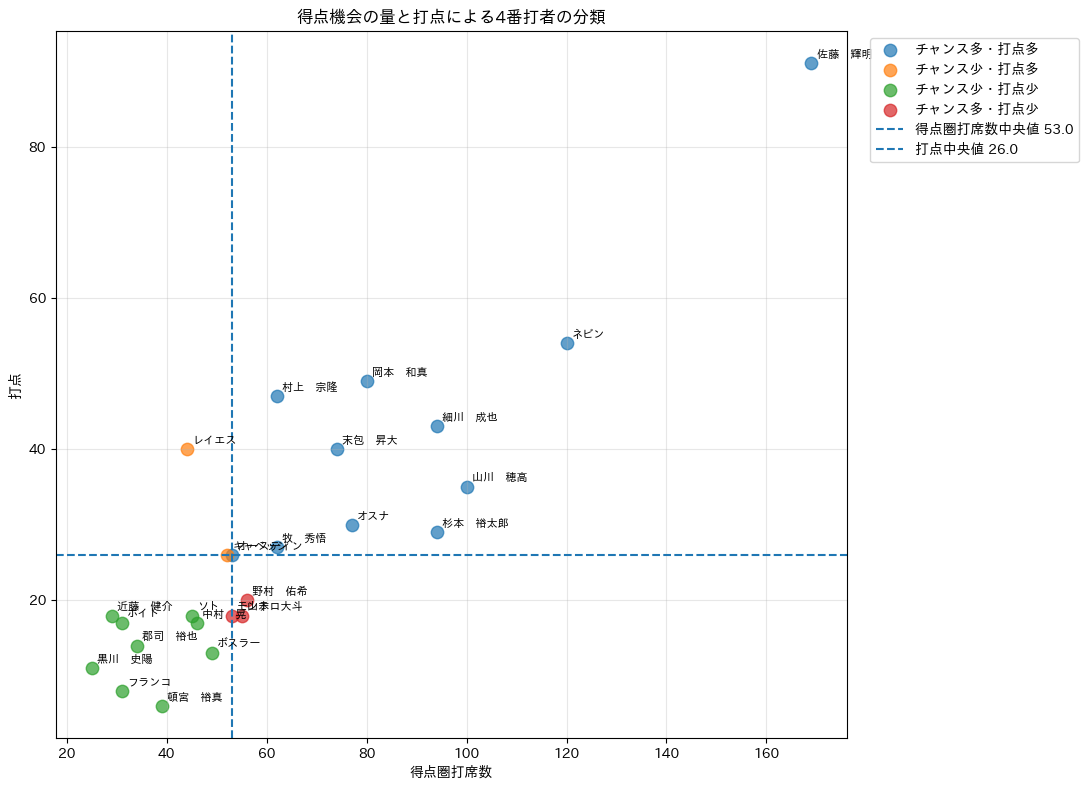

In [31]:
# =========================================================
# 9. 得点圏打席数と打点の4分類散布図
# =========================================================

plt.figure(figsize=(11, 8))

types = df_100[
    "打点タイプ"
].dropna().unique()

for type_name in types:
    type_data = df_100[
        df_100["打点タイプ"] == type_name
    ]

    plt.scatter(
        type_data["得点圏打席数"],
        type_data["打点"],
        s=80,
        alpha=0.7,
        label=type_name
    )

# 中央値の境界線
plt.axvline(
    chance_median,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"得点圏打席数中央値 "
        f"{chance_median:.1f}"
    )
)

plt.axhline(
    rbi_median,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"打点中央値 "
        f"{rbi_median:.1f}"
    )
)

# 選手名
for _, row in df_100.dropna(
    subset=[
        "得点圏打席数",
        "打点"
    ]
).iterrows():

    plt.annotate(
        row["選手名"],
        (
            row["得点圏打席数"],
            row["打点"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("得点圏打席数")
plt.ylabel("打点")
plt.title(
    "得点機会の量と打点による4番打者の分類"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# =========================================================
# 10. タイプ別の人数と平均値
# =========================================================

type_summary = (
    df_100
    .groupby("打点タイプ")
    .agg(
        選手数=("選手名", "count"),
        平均得点圏打席数=("得点圏打席数", "mean"),
        平均打点=("打点", "mean"),
        平均RE24=("RE24", "mean"),
        平均WPA=("WPA", "mean")
    )
    .round(3)
)

display(type_summary)

,選手数,平均得点圏打席数,平均打点,平均RE24,平均WPA
打点タイプ,,,,,
チャンス多・打点多,11,89.545,42.818,15.380,2.227
チャンス多・打点少,3,54.667,18.667,-2.025,0.670
チャンス少・打点多,2,48.000,33.000,17.874,3.023
チャンス少・打点少,9,36.556,13.556,2.310,-0.166


In [33]:
# =========================================================
# 11. 各タイプの注目選手
# =========================================================

for type_name in [
    "チャンス多・打点多",
    "チャンス多・打点少",
    "チャンス少・打点多",
    "チャンス少・打点少"
]:
    print("=" * 60)
    print(type_name)

    display(
        df_100[
            df_100["打点タイプ"] == type_name
        ][
            [
                "選手名",
                "得点圏打席数",
                "打点",
                "RE24",
                "WPA"
            ]
        ].sort_values(
            "打点",
            ascending=False
        )
    )

チャンス多・打点多


,選手名,得点圏打席数,打点,RE24,WPA
42,佐藤 輝明,169,91,47.723,3.238965
11,ネビン,120,54,21.654,0.468037
81,岡本 和真,80,49,28.686,4.366410
93,村上 宗隆,62,47,31.171,4.020346
134,細川 成也,94,43,19.930,3.654191
90,末包 昇大,74,40,10.932,-0.075041
76,山川 穂高,100,35,0.287,0.849737
1,オスナ,77,30,3.214,0.736590
91,杉本 裕太郎,94,29,-8.236,0.965217
113,牧 秀悟,62,27,8.321,5.049012


チャンス多・打点少


,選手名,得点圏打席数,打点,RE24,WPA
152,野村 佑希,56,20,2.118,1.132902
22,モンテロ,53,18,-3.287,1.595811
77,山本 大斗,55,18,-4.906,-0.718523


チャンス少・打点多


,選手名,得点圏打席数,打点,RE24,WPA
23,レイエス,44,40,25.210,4.825634
5,キャベッジ,52,26,10.538,1.219419


チャンス少・打点少


,選手名,得点圏打席数,打点,RE24,WPA
9,ソト,45,18,-1.956,-0.638764
148,近藤 健介,29,18,9.484,1.482278
18,ボイト,31,17,10.230,0.418691
30,中村 晃,46,17,3.365,0.678367
150,郡司 裕也,34,14,9.203,0.776498
19,ボスラー,49,13,-4.350,-1.352659
161,黒川 史陽,25,11,5.203,1.124762
15,フランコ,31,8,-4.178,-1.740724
156,頓宮 裕真,39,6,-6.212,-2.246626
